### Importing Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import scipy.stats as stats
import xgboost as xgb

from scipy.stats import spearmanr
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report, precision_recall_curve, mean_squared_error
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.utils.class_weight import compute_sample_weight
import warnings
warnings.filterwarnings("ignore")

from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, precision_score, recall_score, f1_score, roc_curve
from collections import Counter

from sklearn.linear_model import RidgeCV
from sklearn.metrics import mean_squared_error
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestClassifier

### Loading the dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
file_path = '/content/drive/MyDrive/Loan_default.csv'

In [ ]:
import pandas as pd
df = pd.read_csv(file_path)
df.head()

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0


In [ ]:
df = df.drop(columns=['LoanID'], errors='ignore')

### Understand the structure of the dataset

In [ ]:
df.shape

(255347, 17)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 255347 entries, 0 to 255346
Data columns (total 17 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   Age             255347 non-null  int64  
 1   Income          255347 non-null  int64  
 2   LoanAmount      255347 non-null  int64  
 3   CreditScore     255347 non-null  int64  
 4   MonthsEmployed  255347 non-null  int64  
 5   NumCreditLines  255347 non-null  int64  
 6   InterestRate    255347 non-null  float64
 7   LoanTerm        255347 non-null  int64  
 8   DTIRatio        255347 non-null  float64
 9   Education       255347 non-null  object 
 10  EmploymentType  255347 non-null  object 
 11  MaritalStatus   255347 non-null  object 
 12  HasMortgage     255347 non-null  object 
 13  HasDependents   255347 non-null  object 
 14  LoanPurpose     255347 non-null  object 
 15  HasCoSigner     255347 non-null  object 
 16  Default         255347 non-null  int64  
dtypes: float64

In [ ]:
df.describe()

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Default
count,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000
mean,43.498306,82499.304597,127578.865512,574.264346,59.541976,2.501036,13.492773,36.025894,0.500212,0.116128
std,14.990258,38963.013729,70840.706142,158.903867,34.643376,1.117018,6.636443,16.969330,0.230917,0.320379
min,18.000000,15000.000000,5000.000000,300.000000,0.000000,1.000000,2.000000,12.000000,0.100000,0.000000
25%,31.000000,48825.500000,66156.000000,437.000000,30.000000,2.000000,7.770000,24.000000,0.300000,0.000000
50%,43.000000,82466.000000,127556.000000,574.000000,60.000000,2.000000,13.460000,36.000000,0.500000,0.000000
75%,56.000000,116219.000000,188985.000000,712.000000,90.000000,3.000000,19.250000,48.000000,0.700000,0.000000
max,69.000000,149999.000000,249999.000000,849.000000,119.000000,4.000000,25.000000,60.000000,0.900000,1.000000


### Missing values analysis

In [ ]:
print(df.isnull().sum())

Age               0
Income            0
LoanAmount        0
CreditScore       0
MonthsEmployed    0
NumCreditLines    0
InterestRate      0
LoanTerm          0
DTIRatio          0
Education         0
EmploymentType    0
MaritalStatus     0
HasMortgage       0
HasDependents     0
LoanPurpose       0
HasCoSigner       0
Default           0
dtype: int64


### Explore Target variable - Default

In [ ]:
df['Default'].value_counts()

,count
Default,
0,225694
1,29653


In [ ]:
sns.set(style="whitegrid")

Text(0.5, 1.0, 'Loan Status Distribution')

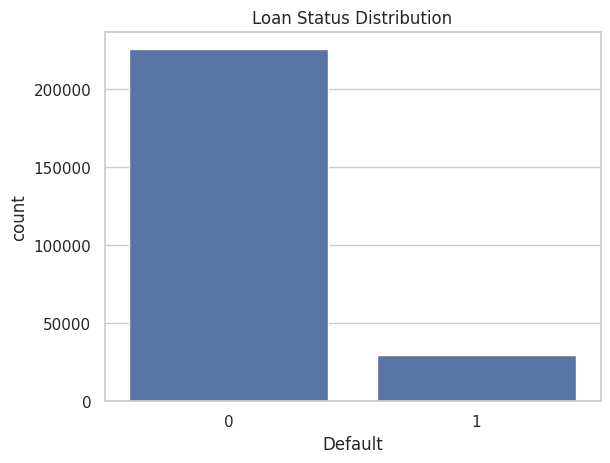

In [ ]:
sns.countplot(data=df, x="Default")
plt.title("Loan Status Distribution")

### Identifying Outliers from the columns required for Hypotheses

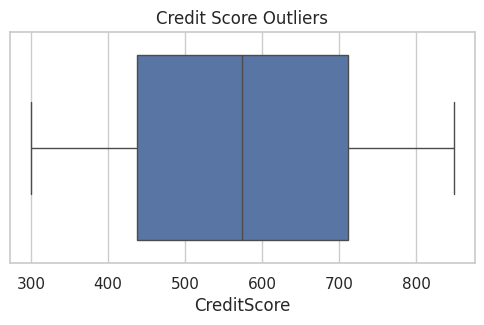

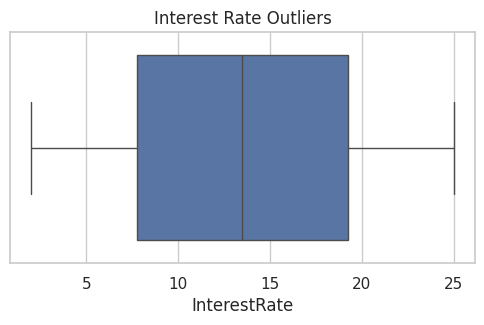

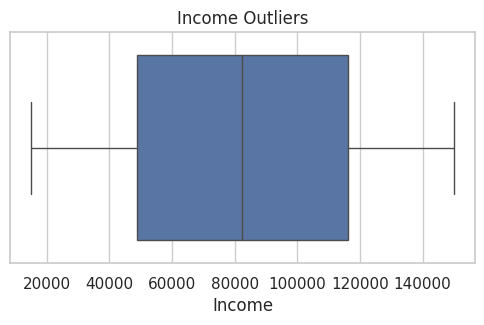

In [ ]:
plt.figure(figsize=(6, 3))
sns.boxplot(x=df['CreditScore'])
plt.title('Credit Score Outliers')
plt.show()

plt.figure(figsize=(6, 3))
sns.boxplot(x=df['InterestRate'])
plt.title('Interest Rate Outliers')
plt.show()

plt.figure(figsize=(6, 3))
sns.boxplot(x=df['Income'])
plt.title('Income Outliers')
plt.show()

### Univariate analysis

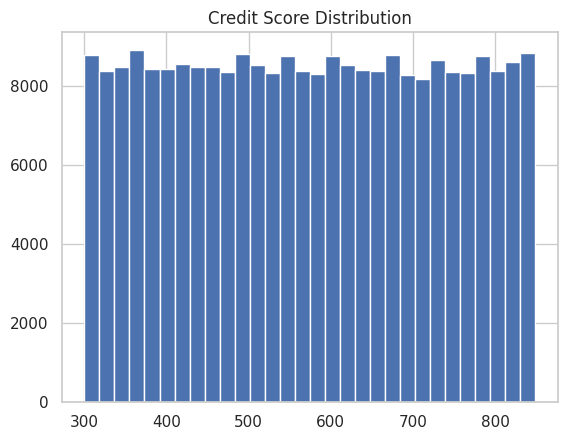

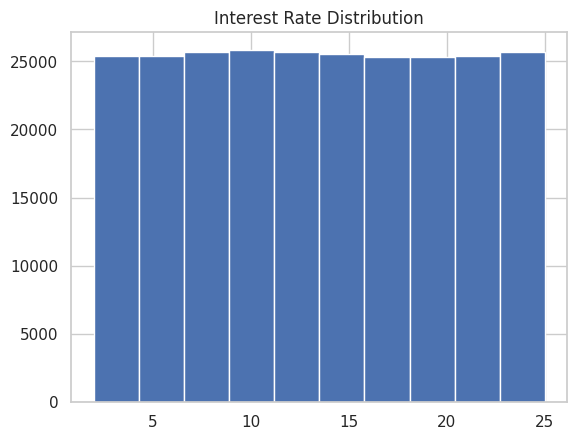

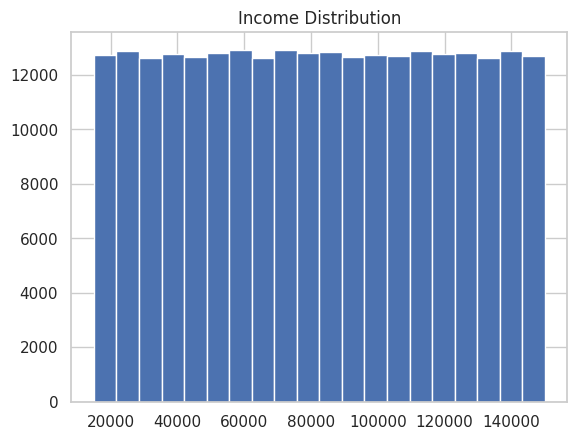

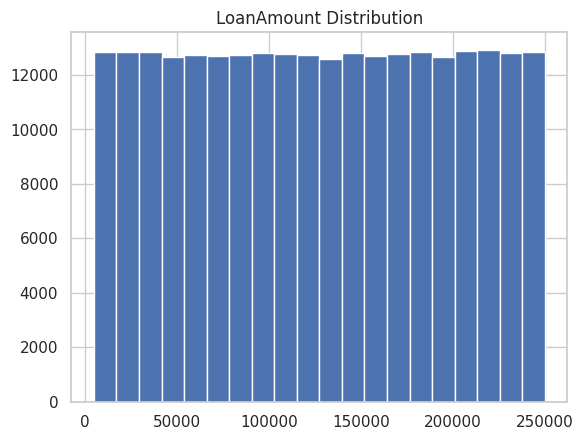

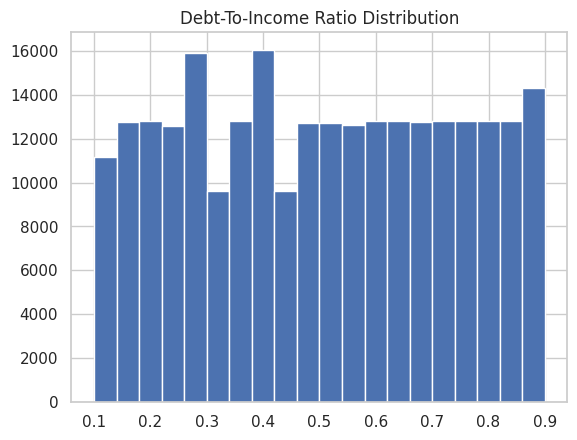

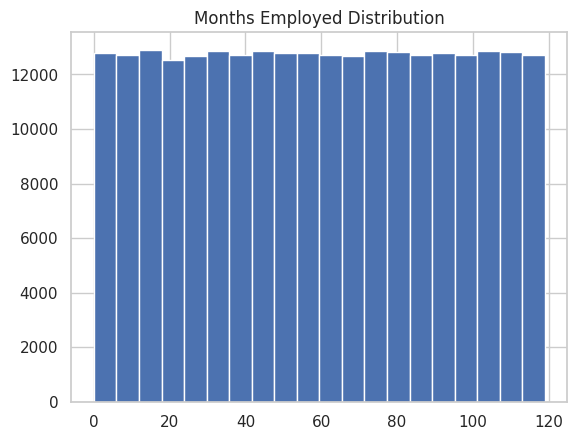

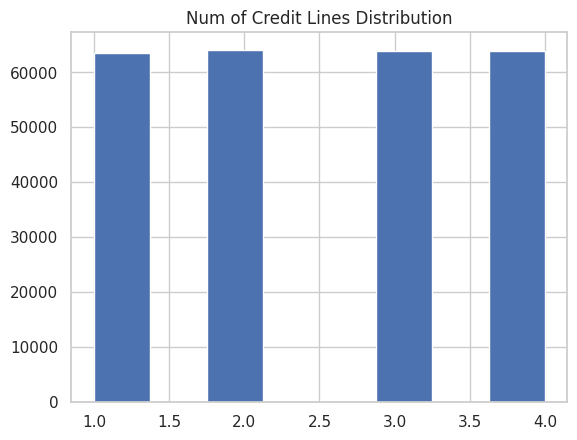

In [ ]:
df['CreditScore'].hist(bins=30)
plt.title("Credit Score Distribution")
plt.show()

df['InterestRate'].hist(bins=10)
plt.title("Interest Rate Distribution")
plt.show()

df['Income'].hist(bins=20)
plt.title("Income Distribution")
plt.show()

df['LoanAmount'].hist(bins=20)
plt.title("LoanAmount Distribution")
plt.show()

df['DTIRatio'].hist(bins=20)
plt.title("Debt-To-Income Ratio Distribution")
plt.show()

df['MonthsEmployed'].hist(bins=20)
plt.title("Months Employed Distribution")
plt.show()

df['NumCreditLines'].hist(bins=8)
plt.title("Num of Credit Lines Distribution")
plt.show()

In [ ]:
distributions = ['norm', 'lognorm', 'expon', 'gamma', 'beta']

In [ ]:
numerical_cols = df.select_dtypes(include=['int64', 'float64', 'uint8']).columns.tolist()
if 'Default' in numerical_cols:
    numerical_cols.remove('Default')

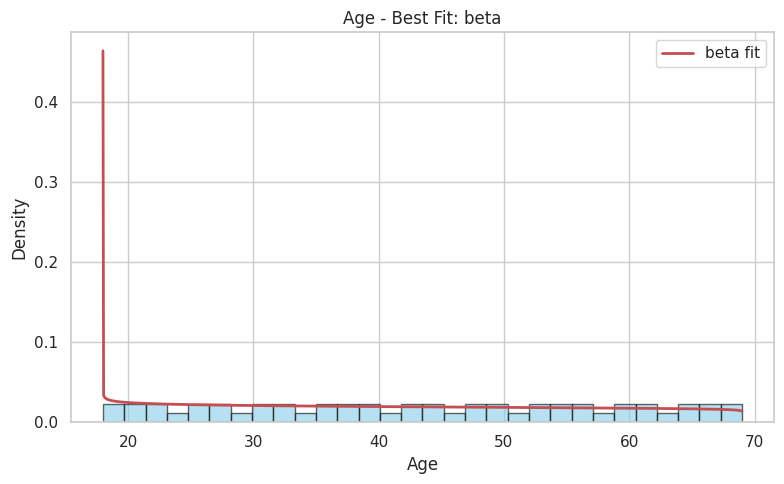

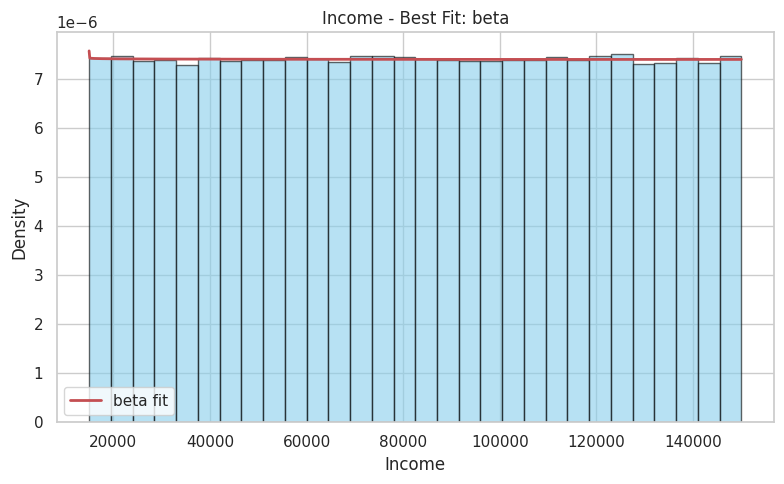

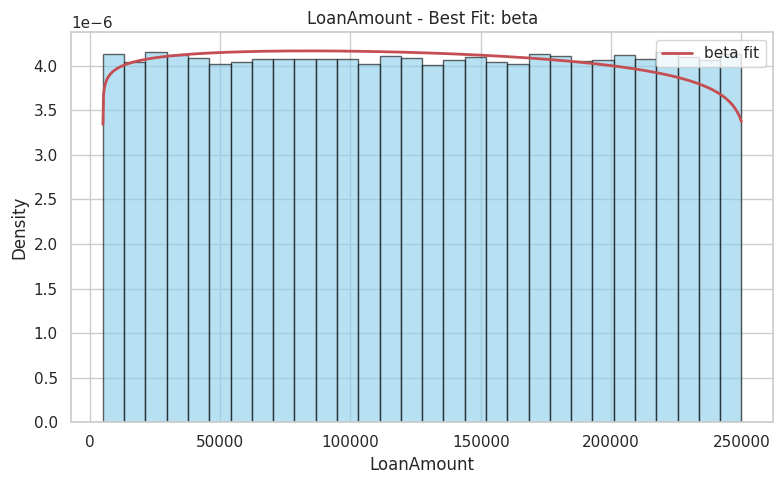

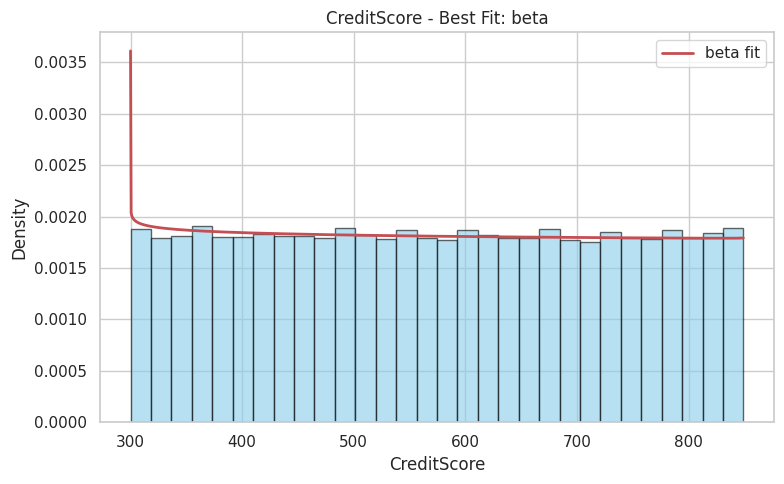

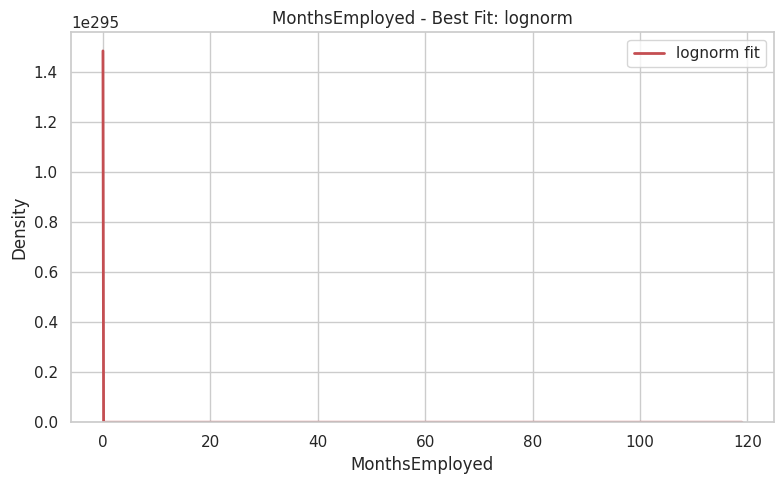

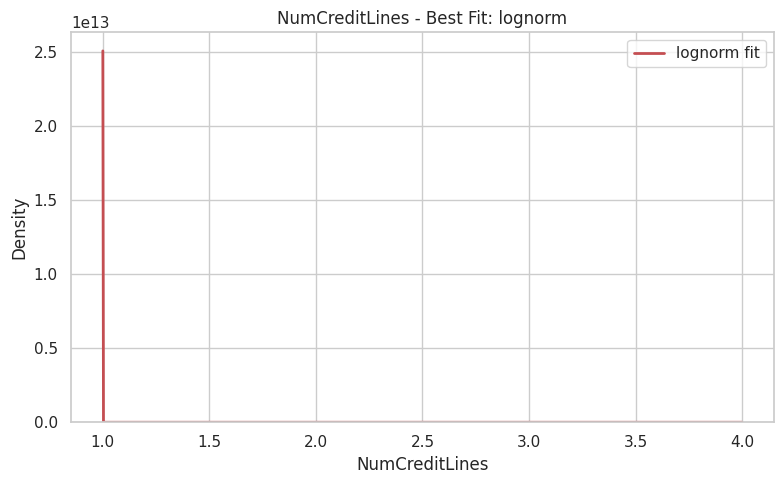

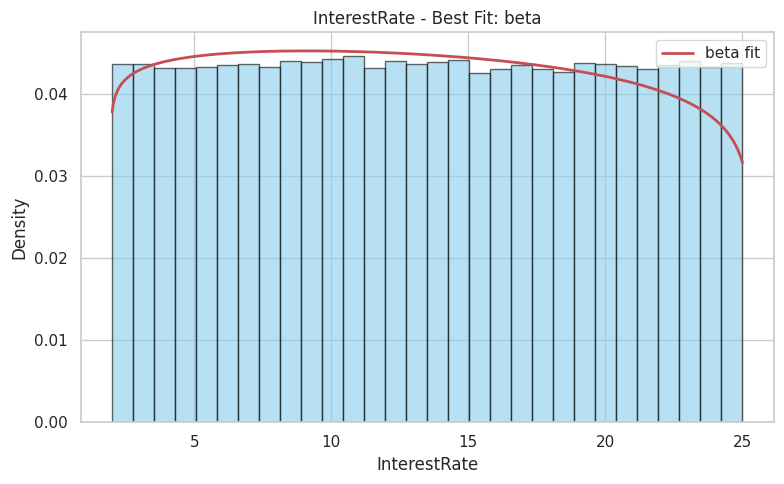

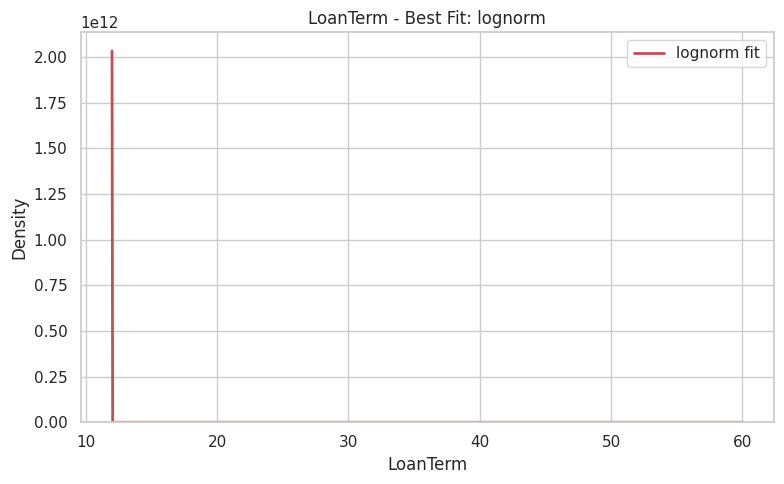

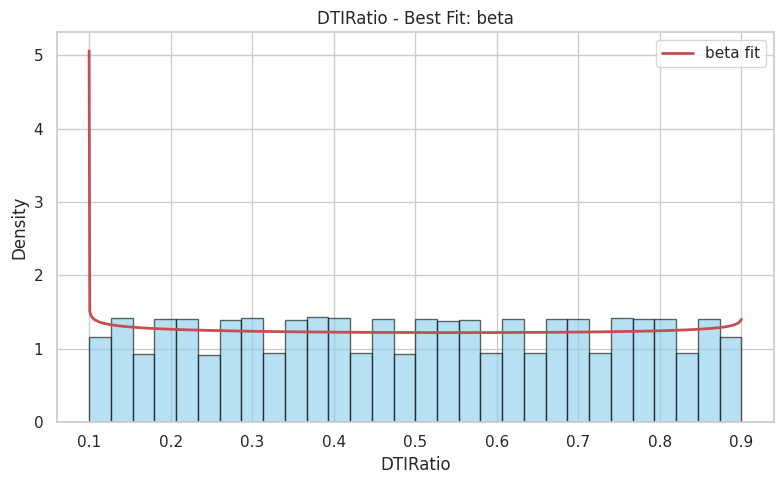

In [ ]:
results = {}

for col in numerical_cols:
    data = df[col].dropna()
    best_fit = None
    best_aic = np.inf
    best_params = None
    best_dist = None

    for dist_name in distributions:
        dist = getattr(stats, dist_name)
        try:
            params = dist.fit(data)
            loglik = np.sum(dist.logpdf(data, *params))
            k = len(params)
            aic = 2 * k - 2 * loglik

            if aic < best_aic:
                best_fit = dist_name
                best_aic = aic
                best_params = params
                best_dist = dist

        except Exception:
            continue

    results[col] = {
        'Best Fit': best_fit,
        'AIC': round(best_aic, 2),
        'Params': np.round(best_params, 3)
    }

    plt.figure(figsize=(8, 5))
    count, bins, _ = plt.hist(data, bins=30, density=True, alpha=0.6, color='skyblue', edgecolor='black')
    x = np.linspace(min(data), max(data), 1000)
    y = best_dist.pdf(x, *best_params)
    plt.plot(x, y, 'r-', lw=2, label=f'{best_fit} fit')
    plt.title(f'{col} - Best Fit: {best_fit}')
    plt.xlabel(col)
    plt.ylabel('Density')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


In [ ]:
fit_results_df = pd.DataFrame(results).T
fit_results_df

,Best Fit,AIC,Params
Age,beta,1985364.56,"[0.914, 1.045, 18.0, 51.057]"
Income,beta,6032870.65,"[0.999, 1.0, 15000.0, 135005.083]"
LoanAmount,beta,6340912.57,"[1.026, 1.054, 4993.864, 247015.777]"
CreditScore,beta,3221489.07,"[0.981, 0.999, 300.0, 549.529]"
MonthsEmployed,lognorm,1647900.47,"[67.933, -0.0, 0.09]"
NumCreditLines,lognorm,-2217011.75,"[15.847, 1.0, 0.0]"
InterestRate,beta,1607257.01,"[1.044, 1.1, 1.946, 23.322]"
LoanTerm,lognorm,-16643.51,"[14.893, 12.0, 0.016]"
DTIRatio,beta,-116595.65,"[0.962, 0.97, 0.1, 0.802]"


### Bivariate Analysis

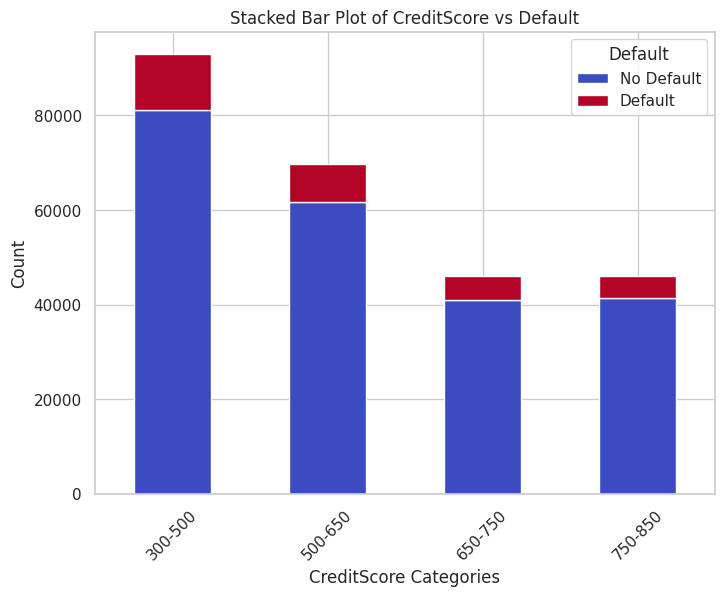

In [ ]:
credit_score_bins = [300, 500, 650, 750, 850]
credit_score_labels = ['300-500', '500-650', '650-750', '750-850']
df['CreditScoreCategory'] = pd.cut(df['CreditScore'], bins=credit_score_bins, labels=credit_score_labels)

credit_score_default = pd.crosstab(df['CreditScoreCategory'], df['Default'])
credit_score_default.plot(kind='bar', stacked=True, colormap='coolwarm', figsize=(8, 6))

plt.title('Stacked Bar Plot of CreditScore vs Default')
plt.xlabel('CreditScore Categories')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend(title='Default', labels=['No Default', 'Default'])
plt.show()

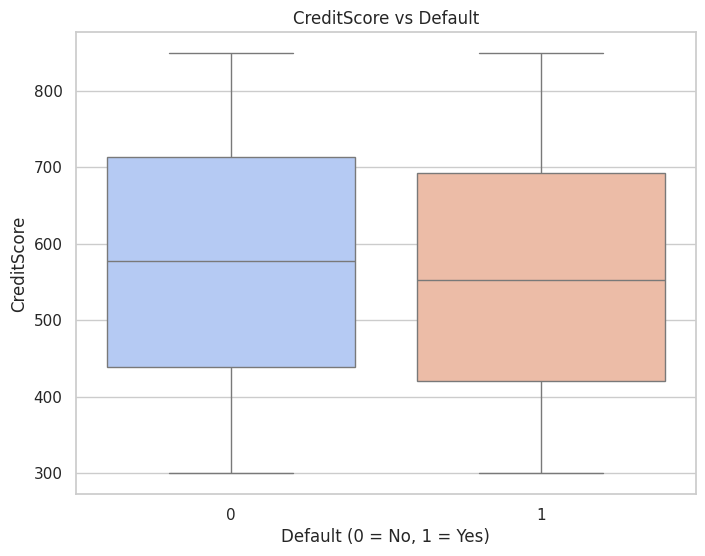

In [ ]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='Default', y='CreditScore', data=df, palette='coolwarm')
plt.title('CreditScore vs Default')
plt.xlabel('Default (0 = No, 1 = Yes)')
plt.ylabel('CreditScore')
plt.show()

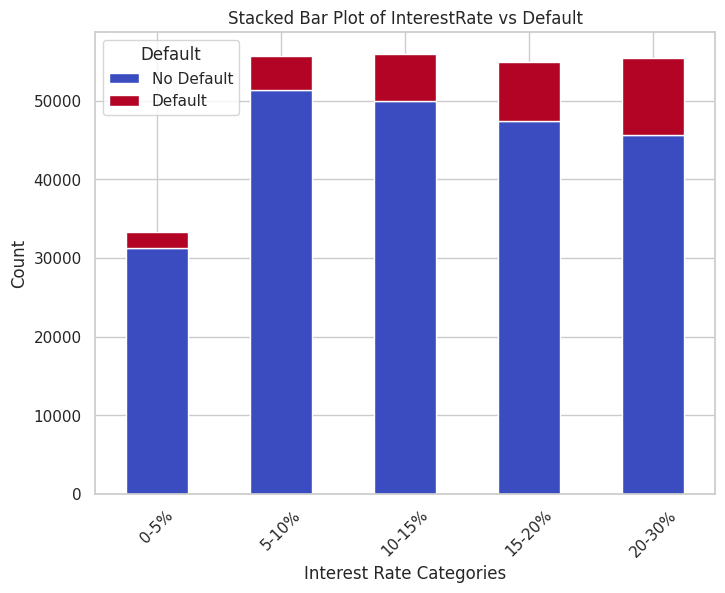

In [ ]:
bins = [0, 5, 10, 15, 20, 30]
labels = ['0-5%', '5-10%', '10-15%', '15-20%', '20-30%']
df['InterestRateCategory'] = pd.cut(df['InterestRate'], bins=bins, labels=labels)

interest_rate_default = pd.crosstab(df['InterestRateCategory'], df['Default'])
interest_rate_default.plot(kind='bar', stacked=True, colormap='coolwarm', figsize=(8, 6))

plt.title('Stacked Bar Plot of InterestRate vs Default')
plt.xlabel('Interest Rate Categories')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend(title='Default', labels=['No Default', 'Default'])
plt.show()

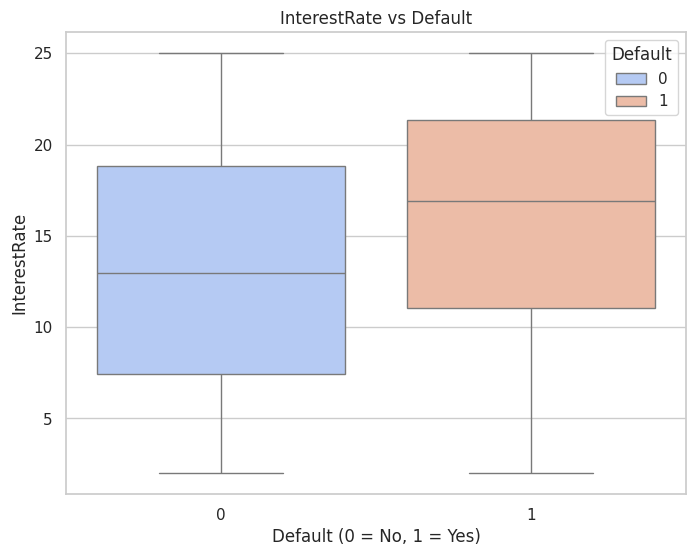

In [ ]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='Default', y='InterestRate', data=df, hue='Default', palette='coolwarm', showfliers=False)
plt.title('InterestRate vs Default')
plt.xlabel('Default (0 = No, 1 = Yes)')
plt.ylabel('InterestRate')
plt.show()

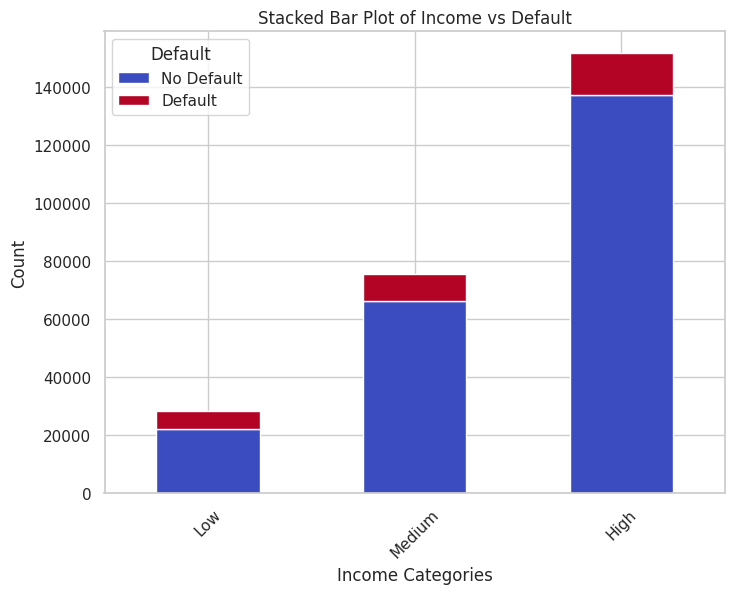

In [ ]:
income_bins = [0, 30000, 70000, 150000]  # Adjust the bins as needed
income_labels = ['Low', 'Medium', 'High']
df['IncomeCategory'] = pd.cut(df['Income'], bins=income_bins, labels=income_labels)

income_default = pd.crosstab(df['IncomeCategory'], df['Default'])
income_default.plot(kind='bar', stacked=True, colormap='coolwarm', figsize=(8, 6))

plt.title('Stacked Bar Plot of Income vs Default')
plt.xlabel('Income Categories')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend(title='Default', labels=['No Default', 'Default'])
plt.show()


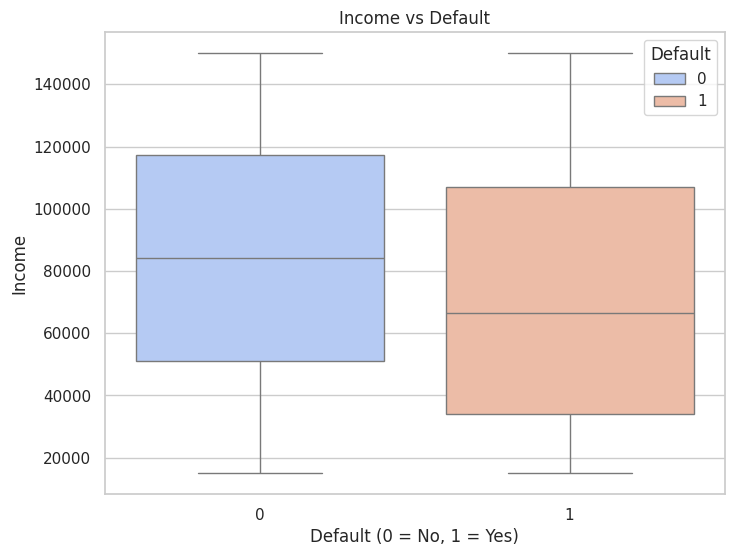

In [ ]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='Default', y='Income', data=df, hue='Default', palette='coolwarm', showfliers=False)
plt.title('Income vs Default')
plt.xlabel('Default (0 = No, 1 = Yes)')
plt.ylabel('Income')
plt.show()

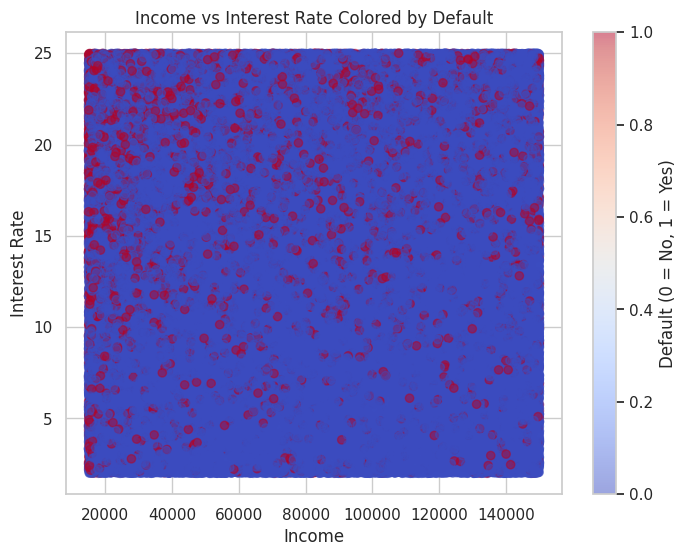

In [ ]:
plt.figure(figsize=(8, 6))
scatter = plt.scatter(df['Income'], df['InterestRate'], c=df['Default'], cmap='coolwarm', alpha=0.5)

plt.xlabel('Income')
plt.ylabel('Interest Rate')
plt.title('Income vs Interest Rate Colored by Default')
plt.colorbar(scatter, label='Default (0 = No, 1 = Yes)')
plt.grid(True)
plt.show()

### Pairs Plot

In [ ]:
# df_subset = df[['CreditScore', 'InterestRate', 'Income','Default']]
# plt.figure(figsize=(10, 8))
# sns.pairplot(df_subset, hue='Default', palette='Set1', plot_kws={'alpha': 0.7})
# plt.show()

### Correlation Matrix

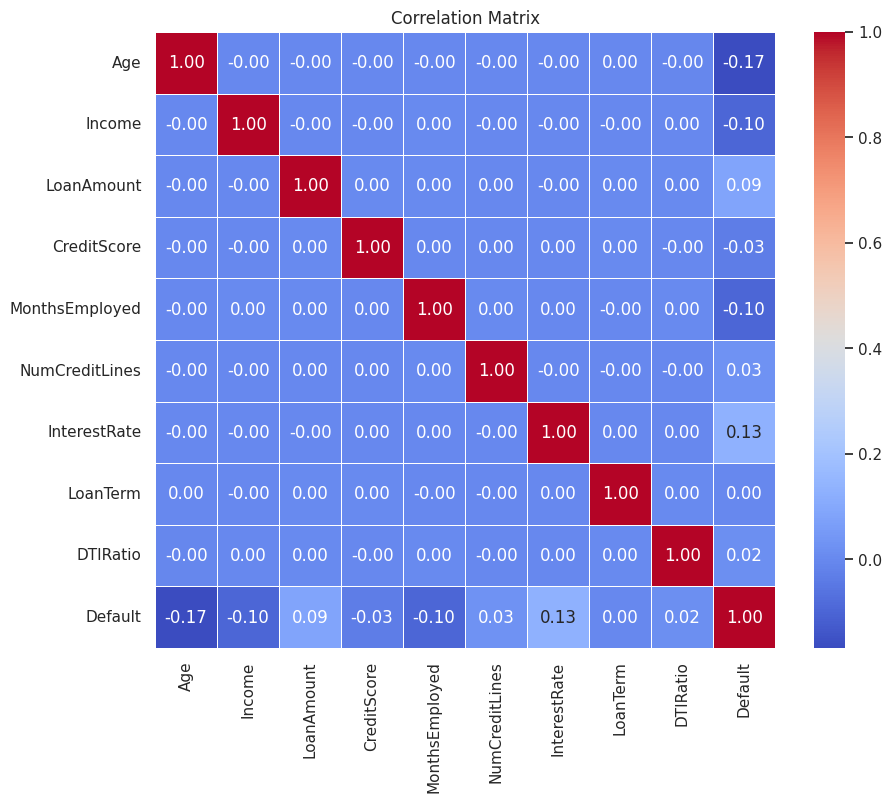

In [ ]:
df_numeric = df.select_dtypes(include=['float64', 'int64'])
df_numeric = df_numeric.fillna(df_numeric.mean())
plt.figure(figsize=(10, 8))
sns.heatmap(df_numeric.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix')
plt.show()

### Feature Selection using RFE

In [ ]:
model = LogisticRegression(max_iter=1000, class_weight='balanced')

In [ ]:
X = df.drop('Default', axis=1)
y = df['Default']
X_encoded = pd.get_dummies(X, drop_first=True)

In [ ]:
rfe = RFE(estimator=model, n_features_to_select=10)
rfe.fit(X_encoded, y)

RFE(estimator=LogisticRegression(class_weight='balanced', max_iter=1000),
    n_features_to_select=10)

In [ ]:
selected_features = X_encoded.columns[rfe.support_]
print("Selected Features by RFE:")
print(selected_features)

Selected Features by RFE:
Index(['DTIRatio', 'EmploymentType_Part-time', 'EmploymentType_Self-employed',
       'EmploymentType_Unemployed', 'MaritalStatus_Married',
       'HasDependents_Yes', 'HasCoSigner_Yes', 'CreditScoreCategory_750-850',
       'IncomeCategory_Medium', 'IncomeCategory_High'],
      dtype='object')


### 1. Do borrowers with lower credit scores have a higher likelihood of loan default?

For this hypothesis, we plan on using Logistic Regression, Boosting, Principal Component Analysis.


[link text](https://)#### Procedure 1: Logistic Regression

In [ ]:
print(df[['CreditScore', 'Default']].isnull().sum())

CreditScore    0
Default        0
dtype: int64


In [ ]:
print(df['Default'].unique())

[0 1]


In [ ]:
df = pd.get_dummies(df, drop_first=True)

In [ ]:
X = df[['CreditScore']]
y = df['Default']

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
model = LogisticRegression(max_iter=1000, class_weight='balanced')

In [ ]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [ ]:
cv_scores = []
y_pred = []

In [ ]:
for train_index, test_index in skf.split(X, y):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    model.fit(X_train_scaled, y_train)

    y_pred_fold = model.predict(X_test_scaled)

    y_pred.extend(y_pred_fold)

    fold_accuracy = model.score(X_test_scaled, y_test)
    cv_scores.append(fold_accuracy)

In [ ]:
print(f"Cross-Validation Accuracy Scores: {cv_scores}")
print(f"Mean Accuracy: {np.mean(cv_scores):.4f}")

Cross-Validation Accuracy Scores: [0.5205012727628745, 0.5158018406109262, 0.5155769644990111, 0.5195911413969335, 0.5175742622726116]
Mean Accuracy: 0.5178


In [ ]:
y_pred_all = cross_val_predict(model, X, y, cv=skf)
y_proba_all = cross_val_predict(model, X_scaled, y, cv=skf, method='predict_proba')[:, 1]
overall_accuracy = accuracy_score(y, y_pred_all)
print(f"Overall Accuracy: {overall_accuracy:.4f}")

Overall Accuracy: 0.5182


In [ ]:
print("\nConfusion Matrix:")
print(confusion_matrix(y, y_pred))
print("\nClassification Report:")
print(classification_report(y, y_pred))


Confusion Matrix:
[[115230 110464]
 [ 15386  14267]]

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.51      0.65    225694
           1       0.11      0.48      0.18     29653

    accuracy                           0.51    255347
   macro avg       0.50      0.50      0.42    255347
weighted avg       0.79      0.51      0.59    255347



In [ ]:
X_with_intercept = sm.add_constant(X).astype(float)
logit_model = sm.Logit(y, X_with_intercept)
result = logit_model.fit()
print("\nLogistic Regression Model Coefficients and P-values:")
print(result.summary())

Optimization terminated successfully.
         Current function value: 0.358555
         Iterations 6

Logistic Regression Model Coefficients and P-values:
                           Logit Regression Results                           
Dep. Variable:                Default   No. Observations:               255347
Model:                          Logit   Df Residuals:                   255345
Method:                           MLE   Df Model:                            1
Date:                Wed, 16 Apr 2025   Pseudo R-squ.:                0.001627
Time:                        00:04:09   Log-Likelihood:                -91556.
converged:                       True   LL-Null:                       -91705.
Covariance Type:            nonrobust   LLR p-value:                 7.269e-67
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const          -1.6477      0.023    -72.447      0.

In [ ]:
y_proba = cross_val_predict(model, X_scaled, y, cv=skf, method='predict_proba')[:, 1]

In [ ]:
acc = accuracy_score(y, y_pred_all)
prec = precision_score(y, y_pred_all)
rec = recall_score(y, y_pred_all)
f1 = f1_score(y, y_pred_all)
roc = roc_auc_score(y, y_proba_all)
cm = confusion_matrix(y, y_pred_all)

print("Classification Metrics (Hypothesis 1 - Logistic Regression using CreditScore only)")
print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1 Score:  {f1:.4f}")
print(f"ROC AUC:   {roc:.4f}")
print("\nConfusion Matrix:")
print(cm)

Classification Metrics (Hypothesis 1 - Logistic Regression using CreditScore only)
Accuracy:  0.5182
Precision: 0.1254
Recall:    0.5268
F1 Score:  0.2025
ROC AUC:   0.5307

Confusion Matrix:
[[116697 108997]
 [ 14032  15621]]


Based on the results from our logistic regression model using Credit Score as the sole predictor, our hypothesis that borrowers with lower credit scores are more likely to default is supported. The model yielded a negative coefficient of -0.0007 for CreditScore with a p-value of 0.000, indicating a statistically significant inverse relationship: as credit score decreases, the likelihood of default increases.

The classification metrics further reinforce this conclusion. Despite a relatively modest ROC AUC score of 0.5307, which suggests limited overall discriminative ability due to using only one feature, the model still achieved a recall of 0.5268, meaning it correctly identified over half of all defaulters. The precision was 0.1254, reflecting the high class imbalance, but the F1 score of 0.2025 shows that the model balances false positives and false negatives reasonably well for a single-variable model.

In summary, both the statistical significance and the observed trend in classification metrics support our hypothesis: borrowers with lower credit scores have a higher likelihood of loan default. This insight can help inform risk assessment strategies in credit evaluation systems.

#### Procedure 2: XGBoosting

In [ ]:
for col in df.select_dtypes(include=["object"]).columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))

In [ ]:
X = df.drop(columns=['Default'])
y = df['Default']

In [ ]:
num_neg = (y == 0).sum()
num_pos = (y == 1).sum()
scale_weight = num_neg / num_pos
print("scale_pos_weight:", scale_weight)

scale_pos_weight: 7.61116919030115


In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
model_cv = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', scale_pos_weight=scale_weight, random_state=42)

cv_scores = cross_val_score(model_cv, X, y, cv=cv, scoring='accuracy')
print(f"\nCross-validated Accuracy Scores: {cv_scores}")
print(f"Average Cross-validated Accuracy: {cv_scores.mean():.4f}")


Cross-validated Accuracy Scores: [0.71225769 0.71462698 0.71732362 0.71518925 0.71798939]
Average Cross-validated Accuracy: 0.7155


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [ ]:
xg_boost_model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', scale_pos_weight=scale_weight)
xg_boost_model.fit(X_train, y_train)
y_pred = xg_boost_model.predict(X_test)
print("XG boost model Accuracy:", accuracy_score(y_test, y_pred))

XG boost model Accuracy: 0.72090594608707


In [ ]:
y_probability = xg_boost_model.predict_proba(X_test)[:, 1]

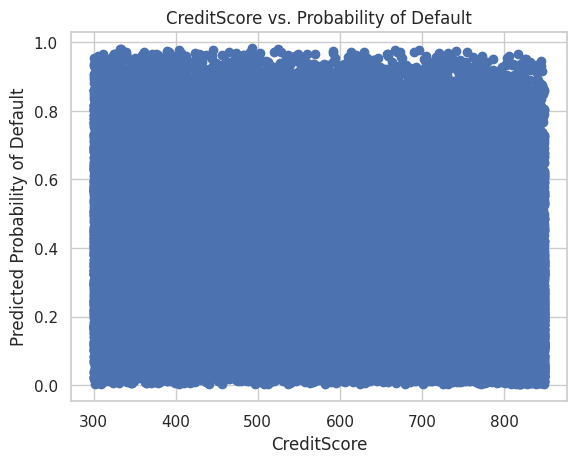

In [ ]:
plt.scatter(X_test["CreditScore"], y_probability)
plt.xlabel("CreditScore")
plt.ylabel("Predicted Probability of Default")
plt.title("CreditScore vs. Probability of Default")
plt.show()

In [ ]:
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc = roc_auc_score(y_test, y_probability)
cm = confusion_matrix(y_test, y_pred)

print("XGBoost Model Evaluation Metrics:")
print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1 Score:  {f1:.4f}")
print(f"ROC AUC:   {roc:.4f}")

print("\nConfusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


XGBoost Model Evaluation Metrics:
Accuracy:  0.7209
Precision: 0.2340
Recall:    0.6141
F1 Score:  0.3389
ROC AUC:   0.7379

Confusion Matrix:
[[49745 17936]
 [ 3444  5480]]

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.73      0.82     67681
           1       0.23      0.61      0.34      8924

    accuracy                           0.72     76605
   macro avg       0.58      0.67      0.58     76605
weighted avg       0.85      0.72      0.77     76605



In [ ]:
correlation, pval = spearmanr(X_test["CreditScore"], y_probability)
print(f"\nSpearman correlation between CreditScore and Probability of Default: {correlation:.3f}")
print(f"P-value: {pval:.5f}")


Spearman correlation between CreditScore and Probability of Default: -0.110
P-value: 0.00000


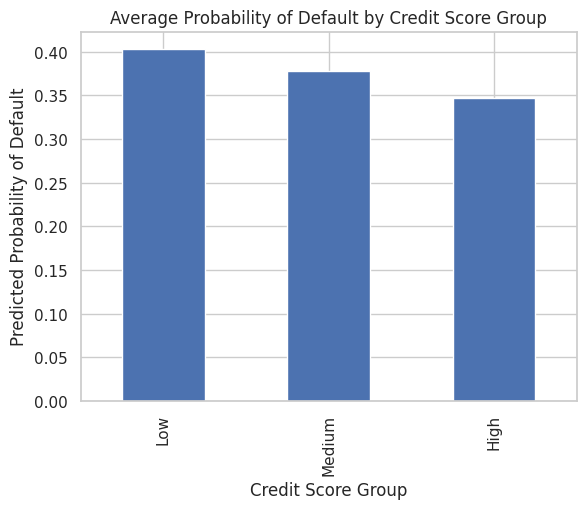

In [ ]:
X_test_copy = X_test.copy()
X_test_copy["prob_default"] = y_probability
X_test_copy["CreditScoreGroup"] = pd.cut(X_test_copy["CreditScore"], bins=[300, 600, 700, 850], labels=["Low", "Medium", "High"])

grouped = X_test_copy.groupby("CreditScoreGroup")["prob_default"].mean()

grouped.plot(kind="bar")
plt.title("Average Probability of Default by Credit Score Group")
plt.ylabel("Predicted Probability of Default")
plt.xlabel("Credit Score Group")
plt.show()


Based on the results from the XGBoost model, our hypothesis that borrowers with lower credit scores are more likely to default on their loans is supported.
We got a negative Spearman correlation of -0.112 between credit score and the predicted probability of default, with a p-value of 0.00000. This proves a statistically significant inverse relationship: as credit scores decrease, the likelihood of default increases.
Additionally, we got a good ROC AUC score of 0.7367, suggesting reliable predictive performance. While the precision for identifying defaulters was relatively low at 0.2333 due to class imbalance, the recall was higher at 0.6139, meaning the model successfully identified a significant number of actual defaults.
The graph shows that borrowers with lower credit scores have a higher average predicted probability of default. This trend supports our hypothesis that lower credit scores are linked to greater default risk.
Therefore, we conclude that lower credit scores are associated with a higher risk of loan default. Borrowers with lower credit scores have a higher likelihood of loan default.

#### Procedure 3: Logistic Regression with Principal Component Analysis

We are using PCA as a preprocessing step for dimension reduction before using Logistic Regression.

In [ ]:
df = pd.get_dummies(df, drop_first=True)

In [ ]:
X = df.drop('Default', axis=1)
y = df['Default']

In [ ]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [ ]:
model = LogisticRegression(max_iter=1000, class_weight='balanced')

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
cv_scores = []
y_pred = []

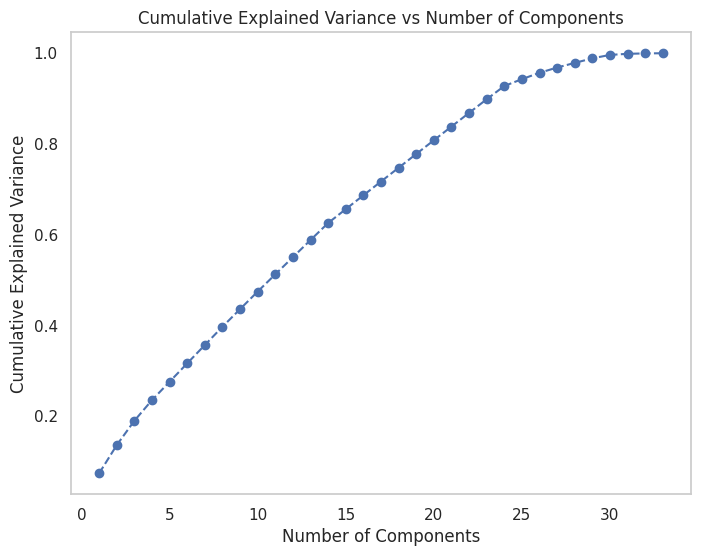

In [ ]:
pca = PCA()
pca.fit(X_scaled)

explained_variance_ratio = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance_ratio)

plt.figure(figsize=(8, 6))
plt.plot(range(1, len(explained_variance_ratio) + 1), cumulative_variance, marker='o', linestyle='--')
plt.title('Cumulative Explained Variance vs Number of Components')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.grid()
plt.show()

In [ ]:
n_components = 24

In [ ]:
for train_index, test_index in skf.split(X, y):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    pca = PCA(n_components=n_components)
    X_train_pca = pca.fit_transform(X_train_scaled)
    X_test_pca = pca.transform(X_test_scaled)

    model.fit(X_train_pca, y_train)

    y_pred_fold = model.predict(X_test_pca)

    y_pred.extend(y_pred_fold)

    fold_accuracy = model.score(X_test_pca, y_test)
    cv_scores.append(fold_accuracy)

In [ ]:
mean_cv_accuracy = np.mean(cv_scores)

In [ ]:
print(f"Cross-Validation Mean Accuracy: {mean_cv_accuracy:.4f}")

Cross-Validation Mean Accuracy: 0.6681


In [ ]:
y_pred_all = cross_val_predict(model, X, y, cv=skf)
overall_accuracy = accuracy_score(y, y_pred_all)
print(f"Overall Accuracy: {overall_accuracy:.4f}")

Overall Accuracy: 0.6750


In [ ]:
acc = accuracy_score(y, y_pred_all)
prec = precision_score(y, y_pred_all)
rec = recall_score(y, y_pred_all)
f1 = f1_score(y, y_pred_all)
roc = roc_auc_score(y, y_pred_all)
cm = confusion_matrix(y, y_pred_all)

print("PCA + Logistic Regression Evaluation Metrics:")
print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1 Score:  {f1:.4f}")
print(f"ROC AUC:   {roc:.4f}")

print("\nConfusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(y, y_pred_all))

PCA + Logistic Regression Evaluation Metrics:
Accuracy:  0.6750
Precision: 0.2137
Recall:    0.6713
F1 Score:  0.3242
ROC AUC:   0.6734

Confusion Matrix:
[[152456  73238]
 [  9748  19905]]

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.68      0.79    225694
           1       0.21      0.67      0.32     29653

    accuracy                           0.68    255347
   macro avg       0.58      0.67      0.56    255347
weighted avg       0.86      0.68      0.73    255347



In [ ]:
pca_component_names = [f'PC{i+1}' for i in range(X_train_pca.shape[1])]
X_train_pca_df = pd.DataFrame(X_train_pca, index=y_train.index, columns=pca_component_names)
X_train_pca_with_intercept = sm.add_constant(X_train_pca_df)

logit_model = sm.Logit(y_train, X_train_pca_with_intercept)
result = logit_model.fit()
print(result.summary())

Optimization terminated successfully.
         Current function value: 0.320376
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:                Default   No. Observations:               204278
Model:                          Logit   Df Residuals:                   204253
Method:                           MLE   Df Model:                           24
Date:                Wed, 16 Apr 2025   Pseudo R-squ.:                  0.1079
Time:                        00:13:30   Log-Likelihood:                -65446.
converged:                       True   LL-Null:                       -73363.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -2.3409      0.009   -266.707      0.000      -2.358      -2.324
PC1           -0.1583      0.

In [ ]:
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f'PC{i+1}' for i in range(pca.n_components_)],
    index=X.columns  # these are the original features
)

In [ ]:
credit_score_loadings = loadings.loc['CreditScore'].sort_values(key=abs, ascending=False)
print("CreditScore loadings on PCA components (sorted by absolute value):")
print(credit_score_loadings)


CreditScore loadings on PCA components (sorted by absolute value):
PC3     0.661962
PC24    0.458671
PC14   -0.072441
PC23    0.037139
PC20   -0.027209
PC19    0.023423
PC11   -0.022107
PC4    -0.018950
PC16    0.016504
PC5     0.014071
PC6    -0.012970
PC15    0.009487
PC21   -0.009173
PC10    0.008946
PC18   -0.008565
PC13   -0.006095
PC22   -0.005909
PC7    -0.004269
PC1    -0.004023
PC17   -0.003360
PC2    -0.002884
PC9    -0.002772
PC8     0.001287
PC12    0.001260
Name: CreditScore, dtype: float64


From the PCA loadings, we observed that PC3 and PC24 had the strongest contributions from CreditScore, with loading values of 0.662 and 0.459, respectively. When inspecting the logistic regression results, both components showed negative coefficients (PC3: -0.0747, PC24: -0.0824) and p-values of 0, indicating statistical significance and a reliable inverse relationship with loan default probability.

This confirms that lower values of CreditScore (as captured by PC3 and PC24) are associated with higher likelihoods of default. Additionally, the model achieved a recall of 0.6713 and an ROC AUC of 0.6734, suggesting it was effective in identifying a substantial portion of defaulters, even under dimensionality reduction.

Therefore, these findings support our hypothesis: borrowers with lower credit scores are at greater risk of loan default, even when credit score information is embedded within principal components.

#### Comparison for Hypothesis 1

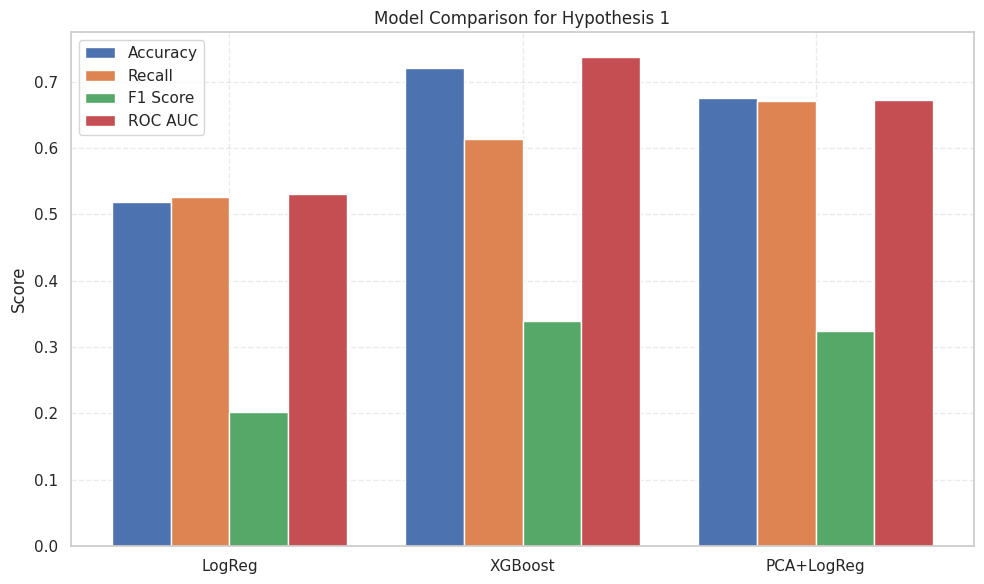

In [ ]:
models = ['LogReg', 'XGBoost', 'PCA+LogReg']
accuracy = [0.5182, 0.7209, 0.6750]
recall =   [0.5268,  0.6141,  0.6713]
f1 =       [0.2025,  0.3389,  0.3242]
auc =      [0.5307,  0.7379,  0.6734]

x = np.arange(len(models))
width = 0.2

plt.figure(figsize=(10, 6))
plt.bar(x - 1.5*width, accuracy, width, label='Accuracy')
plt.bar(x - 0.5*width, recall, width, label='Recall')
plt.bar(x + 0.5*width, f1, width, label='F1 Score')
plt.bar(x + 1.5*width, auc, width, label='ROC AUC')

plt.xticks(x, models)
plt.ylabel('Score')
plt.title('Model Comparison for Hypothesis 1')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

### 2. How does the interest rate impact the likelihood of default across different income levels?


Procedure 1: Multiple Logistic Regression

In [ ]:
df = pd.get_dummies(df, drop_first=True)

In [ ]:
df['Income_InterestRate'] = df['Income'] * df['InterestRate']

In [ ]:
X = df[['Income', 'InterestRate', 'Income_InterestRate']]
y = df['Default']

In [ ]:
scaler = StandardScaler()
X.loc[:, ['Income', 'InterestRate', 'Income_InterestRate']] = scaler.fit_transform(X[['Income', 'InterestRate', 'Income_InterestRate']])

In [ ]:
log_reg = LogisticRegression(solver='liblinear', class_weight='balanced')
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [ ]:
cv_scores = cross_val_score(log_reg, X, y, cv=cv, scoring='roc_auc')

In [ ]:
print(f"Cross-validation ROC AUC Scores: {cv_scores}")
print(f"Mean ROC AUC Score: {np.mean(cv_scores):.4f}")

Cross-validation ROC AUC Scores: [0.64706435 0.64275947 0.64508368 0.64663096 0.64888422]
Mean ROC AUC Score: 0.6461


In [ ]:
log_reg.fit(X, y)

LogisticRegression(class_weight='balanced', solver='liblinear')

In [ ]:
y_prob = log_reg.predict_proba(X)[:, 1]

In [ ]:
y_pred = log_reg.predict(X)
print(classification_report(y, y_pred))
print(f"ROC AUC Score on full data: {roc_auc_score(y, y_prob):.4f}")

              precision    recall  f1-score   support

           0       0.92      0.59      0.72    225694
           1       0.17      0.63      0.26     29653

    accuracy                           0.59    255347
   macro avg       0.54      0.61      0.49    255347
weighted avg       0.83      0.59      0.66    255347

ROC AUC Score on full data: 0.6461


In [ ]:
coefficients = pd.DataFrame(log_reg.coef_.flatten(), index=X.columns, columns=['Coefficient'])
print(coefficients)

                     Coefficient
Income                 -0.345073
InterestRate            0.392768
Income_InterestRate     0.058316


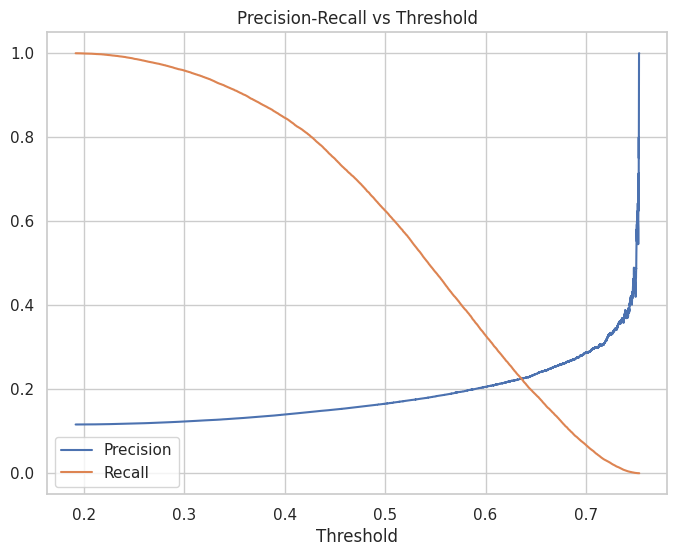

In [ ]:
precisions, recalls, thresholds = precision_recall_curve(y, y_prob)

plt.figure(figsize=(8, 6))
plt.plot(thresholds, precisions[:-1], label="Precision")
plt.plot(thresholds, recalls[:-1], label="Recall")
plt.xlabel("Threshold")
plt.title("Precision-Recall vs Threshold")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
best_index = f1_scores.argmax()
best_threshold = thresholds[best_index]

print(f"Best threshold based on F1: {best_threshold:.3f}")

Best threshold based on F1: 0.534


In [ ]:
log_reg.fit(X, y)

y_prob = log_reg.predict_proba(X)[:, 1]

# y_pred = (y_prob >= 0.5).astype(int)
#Threshold Tuning
threshold = 0.534
y_pred = (y_prob >= threshold).astype(int)

accuracy = accuracy_score(y, y_pred)
print(f"Accuracy of the Multiple Logistic Regression model: {accuracy:.4f}")

precision = precision_score(y, y_pred)
recall = recall_score(y, y_pred)
f1 = f1_score(y, y_pred)
roc_auc = roc_auc_score(y, y_prob)

print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")
print(f"ROC AUC Score: {roc_auc:.4f}")

Accuracy of the Multiple Logistic Regression model: 0.6598
Precision: 0.1770
Recall: 0.5286
F1-Score: 0.2651
ROC AUC Score: 0.6461


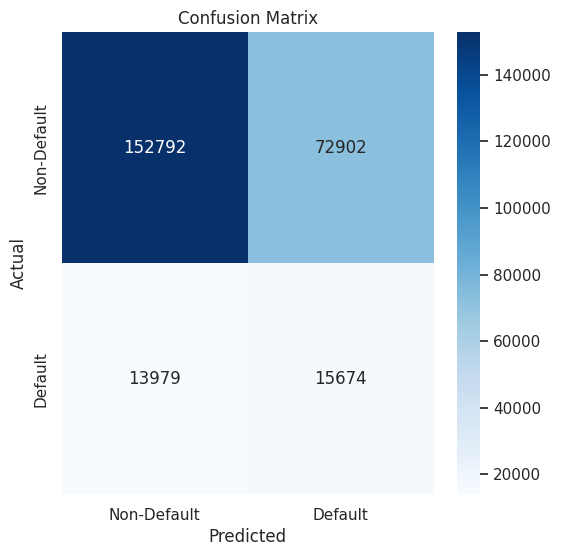

True Negatives: 152792
False Positives: 72902
False Negatives: 13979
True Positives: 15674


In [ ]:
cm = confusion_matrix(y, y_pred)

plt.figure(figsize=(6,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Non-Default", "Default"], yticklabels=["Non-Default", "Default"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

tn, fp, fn, tp = cm.ravel()

print(f"True Negatives: {tn}")
print(f"False Positives: {fp}")
print(f"False Negatives: {fn}")
print(f"True Positives: {tp}")

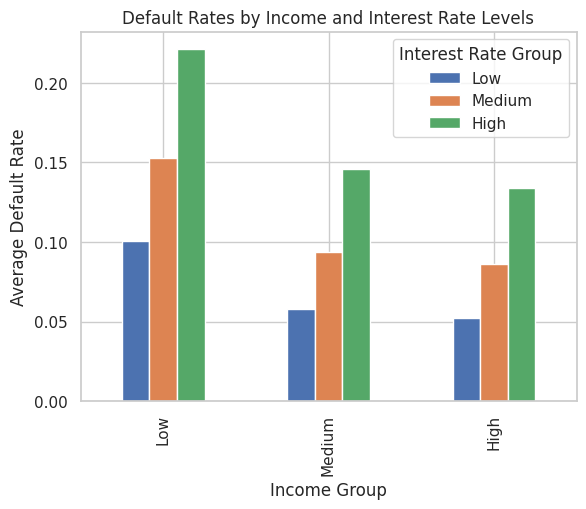

In [ ]:
df_vis = df.copy()
df_vis["IncomeGroup"] = pd.qcut(df_vis["Income"], q=3, labels=["Low", "Medium", "High"])
df_vis["RateGroup"] = pd.qcut(df_vis["InterestRate"], q=3, labels=["Low", "Medium", "High"])

default_rates = df_vis.groupby(["IncomeGroup", "RateGroup"])["Default"].mean().unstack()

default_rates.plot(kind="bar")
plt.title("Default Rates by Income and Interest Rate Levels")
plt.ylabel("Average Default Rate")
plt.xlabel("Income Group")
plt.legend(title="Interest Rate Group")
plt.show()


We used multiple logistic regression to prove whether higher interest rates increase default risk more among lower-income borrowers.

The positive coefficient of the interaction term (Income × InterestRate: 0,0583) indicates that income incluences how borrowers respond to rising interest rates, aligning with the hypothesis.This suggests that lower-income groups may be more vulnerable to interest rate hikes. However, the effect size was small, and while the model achieved a reasonable recall (0.5286), its overall predictive power was moderate (ROC AUC: 0.6461), which is expected given the complexity of the hypothesis and the nature of the data.
Our findings do suggest a possible relationship, especially with more granular income segmentation or external validation.
The barplot of Default Rates by Income and Interest Rate Levels shows that default rates are highest for low-income borrowers when interest rates are also high.
While for higher income groups show a lower average default rate even for high interest rate, suggesting they are less sensitive to rate changes.
The model provides partial evidence that lower-income borrowers may be more affected and vulnerable to higher interest rates resulting in likelyhood of default.


#### Procedure 2: Linear Discriminant Analysis

In [ ]:
X = df[['InterestRate', 'Income']].copy()
y = df['Default']
X['Interest_Income'] = X['InterestRate'] * X['Income']

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
lda = LinearDiscriminantAnalysis()

In [ ]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(lda, X_scaled, y, cv=skf, scoring='accuracy')
y_pred_all = cross_val_predict(lda, X_scaled, y, cv=skf)
y_proba = cross_val_predict(lda, X_scaled, y, cv=skf, method='predict_proba')[:, 1]

In [ ]:
precisions, recalls, thresholds = precision_recall_curve(y, y_proba)

f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)

best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print(f"Best threshold (based on F1 score): {best_threshold:.3f}")
#print(f"Precision: {precisions[best_idx]:.3f}")
#print(f"Recall:    {recalls[best_idx]:.3f}")
#print(f"F1 Score:  {f1_scores[best_idx]:.3f}")

Best threshold (based on F1 score): 0.128


In [ ]:
#Threshold tuning
threshold = 0.128
y_pred_thresh = (y_proba >= threshold).astype(int)

In [ ]:
print(f"Cross-Validation Accuracy Scores: {cv_scores}")
print(f"Mean Accuracy: {np.mean(cv_scores):.4f}")

Cross-Validation Accuracy Scores: [0.88386528 0.88386528 0.88388259 0.88388259 0.88386301]
Mean Accuracy: 0.8839


In [ ]:
print("\nOverall Accuracy:", accuracy_score(y, y_pred_thresh))
print("\nConfusion Matrix:")
print(confusion_matrix(y, y_pred_thresh))
print("\nClassification Report:")
print(classification_report(y, y_pred_thresh))


Overall Accuracy: 0.674995202606649

Confusion Matrix:
[[157629  68065]
 [ 14924  14729]]

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.70      0.79    225694
           1       0.18      0.50      0.26     29653

    accuracy                           0.67    255347
   macro avg       0.55      0.60      0.53    255347
weighted avg       0.83      0.67      0.73    255347



In [ ]:
precision = precision_score(y, y_pred_thresh)
recall = recall_score(y, y_pred_thresh)
f1 = f1_score(y, y_pred_thresh)
roc_auc = roc_auc_score(y, y_proba)

print(f"Precision:  {precision:.4f}")
print(f"Recall:     {recall:.4f}")
print(f"F1 Score:   {f1:.4f}")
print(f"ROC AUC:    {roc_auc:.4f}")

Precision:  0.1779
Recall:     0.4967
F1 Score:   0.2620
ROC AUC:    0.6428


In [ ]:
lda.fit(X_scaled, y)
print("\nLDA Coefficients (for the linear discriminants):")
for feature, coef in zip(X.columns, lda.coef_[0]):
    print(f"{feature}: {coef:.4f}")


LDA Coefficients (for the linear discriminants):
InterestRate: 0.5945
Income: -0.1507
Interest_Income: -0.2540


We used Linear Discriminant Analysis (LDA) to test whether higher interest rates increase default risk more among lower-income borrowers. The model used InterestRate, Income, and their interaction (Interest × Income) as predictors.

The coefficient for InterestRate was positive (0.5945), while both Income (-0.1507) and the interaction term (-0.2540) were negative. This suggests that higher interest rates increase default risk, especially for lower-income borrowers.

After threshold tuning (optimal threshold = 0.128), the model achieved 0.6750 accuracy, 0.4967 recall, and a ROC AUC of 0.6428. While overall predictive power was moderate, these results support the hypothesis that lower-income borrowers are more affected by rising interest rates.

#### Procedure 3: Random Forest

In [ ]:
rf_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [ ]:
rf_thresholds = np.arange(0.1, 0.9, 0.05)
rf_f1_scores_across_folds = np.zeros(len(rf_thresholds))

In [ ]:
for rf_train_idx, rf_val_idx in rf_cv.split(X, y):
    X_rf_train, X_rf_val = X.iloc[rf_train_idx], X.iloc[rf_val_idx]
    y_rf_train, y_rf_val = y.iloc[rf_train_idx], y.iloc[rf_val_idx]

    rf_cv_model = RandomForestClassifier(n_estimators=50, class_weight='balanced', random_state=42)
    rf_cv_model.fit(X_rf_train, y_rf_train)

    y_rf_val_prob = rf_cv_model.predict_proba(X_rf_val)[:, 1]

    for i, t in enumerate(rf_thresholds):
        y_rf_val_pred = (y_rf_val_prob >= t).astype(int)
        rf_f1 = f1_score(y_rf_val, y_rf_val_pred, zero_division=0)
        rf_f1_scores_across_folds[i] += rf_f1

In [ ]:
rf_avg_f1_scores = rf_f1_scores_across_folds / rf_cv.get_n_splits()
rf_best_idx = np.argmax(rf_avg_f1_scores)
rf_best_threshold = rf_thresholds[rf_best_idx]
rf_best_f1 = rf_avg_f1_scores[rf_best_idx]

In [ ]:
print(f"\nBest Random Forest Threshold from Cross Validation: {rf_best_threshold:.2f}, Avg F1-Score: {rf_best_f1:.4f}")


Best Random Forest Threshold from Cross Validation: 0.15, Avg F1-Score: 0.3294


In [ ]:
rf_final_model = RandomForestClassifier(n_estimators=50, class_weight='balanced', random_state=42)
rf_final_model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=50,
                       random_state=42)

In [ ]:
y_rf_test_prob = rf_final_model.predict_proba(X_test)[:, 1]
y_rf_test_pred = (y_rf_test_prob >= rf_best_threshold).astype(int)

In [ ]:
print("\nFinal Random Forest Model Evaluation on Test Set:")
print(f"Best Threshold Used      : {rf_best_threshold:.2f}")
print(f"Accuracy                 : {accuracy_score(y_test, y_rf_test_pred):.4f}")
print(f"Precision                : {precision_score(y_test, y_rf_test_pred):.4f}")
print(f"Recall                   : {recall_score(y_test, y_rf_test_pred):.4f}")
print(f"F1-Score                 : {f1_score(y_test, y_rf_test_pred):.4f}")
print(f"ROC AUC                  : {roc_auc_score(y_test, y_rf_test_prob):.4f}")


Final Random Forest Model Evaluation on Test Set:
Best Threshold Used      : 0.15
Accuracy                 : 0.7431
Precision                : 0.2343
Recall                   : 0.5345
F1-Score                 : 0.3258
ROC AUC                  : 0.7167



Confusion Matrix Values (Test Set):
True Positives:  3170
True Negatives:  34781
False Positives: 10357
False Negatives: 2761


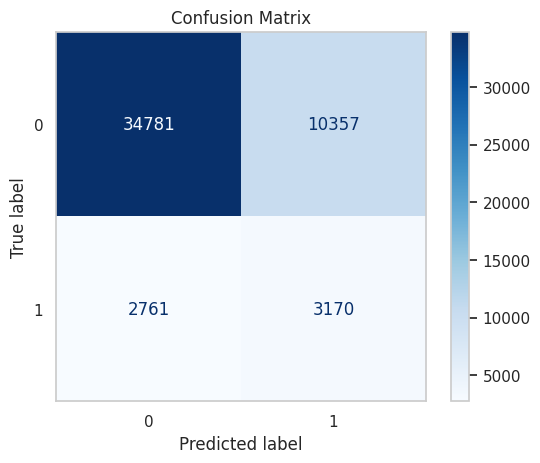

In [ ]:
rf_cm = confusion_matrix(y_test, y_rf_test_pred)
tn, fp, fn, tp = rf_cm.ravel()

print("\nConfusion Matrix Values (Test Set):")
print(f"True Positives:  {tp}")
print(f"True Negatives:  {tn}")
print(f"False Positives: {fp}")
print(f"False Negatives: {fn}")

disp = ConfusionMatrixDisplay(confusion_matrix=rf_cm, display_labels=rf_final_model.classes_)
disp.plot(cmap='Blues', values_format='d')
plt.title("Confusion Matrix")
plt.grid(False)
plt.show()

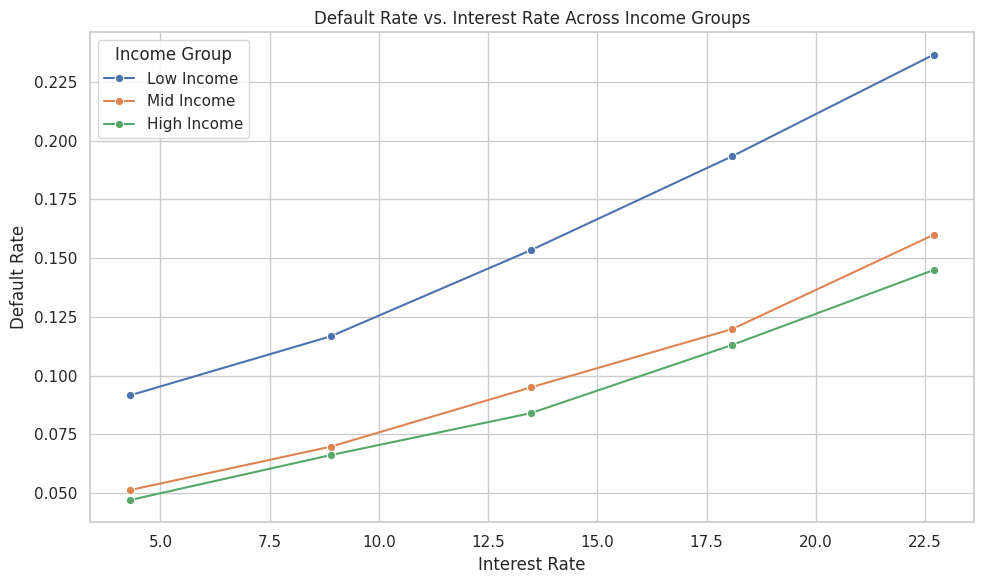

In [ ]:
df_rf = X.copy()
df_rf['Default'] = y
df_rf['Income_Bin'] = pd.qcut(df_rf['Income'], q=3, labels=['Low Income', 'Mid Income', 'High Income'])
df_rf['InterestRate_Bin'] = pd.qcut(df_rf['InterestRate'], q=5)

grouped = df_rf.groupby(['Income_Bin', 'InterestRate_Bin'])['Default'].mean().reset_index()
grouped['InterestRate_Center'] = grouped['InterestRate_Bin'].apply(lambda x: x.mid)

plt.figure(figsize=(10, 6))
sns.lineplot(data=grouped, x='InterestRate_Center', y='Default', hue='Income_Bin', marker='o')

plt.title("Default Rate vs. Interest Rate Across Income Groups")
plt.xlabel("Interest Rate")
plt.ylabel("Default Rate")
plt.grid(True)
plt.legend(title="Income Group")
plt.tight_layout()
plt.show()


We used a Random Forest model to examine whether interest rates have a stronger effect on default risk for lower-income borrowers. After threshold tuning (optimal threshold = 0.15), the final model achieved a recall of 0.5345, precision of 0.2343, and an F1-score of 0.3258. The ROC AUC of 0.7167 indicates solid discriminatory ability, and an overall accuracy of 0.7431 confirms decent performance on the test set.

Notably, the line plot of default rates across income and interest rate groups showed that default risk increased more sharply for low-income borrowers as interest rates rose, compared to higher-income groups. This visual trend supports our hypothesis.

While not definitive, the model provides meaningful evidence that rising interest rates may disproportionately affect lower-income borrowers, supporting the hypothesis and highlighting the need for more targeted lending strategies.

#### Comparison for Hypothesis 2

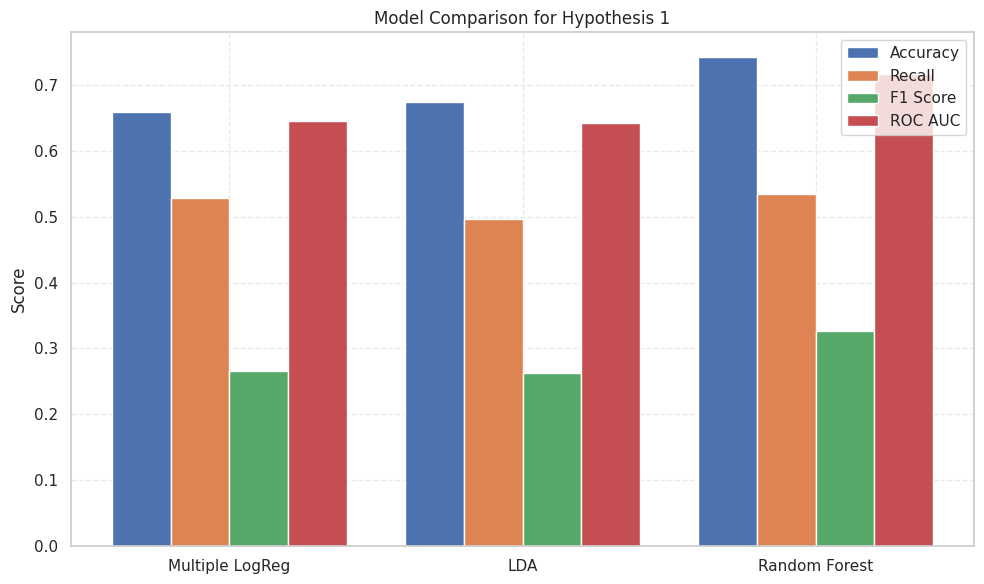

In [ ]:
models = ['Multiple LogReg', 'LDA', 'Random Forest']
accuracy = [0.6598, 0.6750, 0.7431]
recall =   [0.5286, 0.4967, 0.5345]
f1 =       [0.2651, 0.2620, 0.3258]
auc =      [0.6461, 0.6428, 0.7167]

x = np.arange(len(models))
width = 0.2

plt.figure(figsize=(10, 6))
plt.bar(x - 1.5*width, accuracy, width, label='Accuracy')
plt.bar(x - 0.5*width, recall, width, label='Recall')
plt.bar(x + 0.5*width, f1, width, label='F1 Score')
plt.bar(x + 1.5*width, auc, width, label='ROC AUC')

plt.xticks(x, models)
plt.ylabel('Score')
plt.title('Model Comparison for Hypothesis 1')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

### 3. How will economic downturns or policy changes affect loan default rates over the next decade?


#### Procedure 1: Logistic Regression

In [ ]:
X = df.drop(columns=['Default'])
y = df['Default']

In [ ]:
X = pd.get_dummies(X, drop_first=True)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
model = LogisticRegression(max_iter=1000, class_weight='balanced')
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [ ]:
cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=skf, scoring='accuracy')
y_train_pred = cross_val_predict(model, X_train_scaled, y_train, cv=skf)
y_train_proba = cross_val_predict(model, X_train_scaled, y_train, cv=skf, method='predict_proba')[:, 1]

In [ ]:
model.fit(X_train_scaled, y_train)
y_test_pred = model.predict(X_test_scaled)
y_test_proba = model.predict_proba(X_test_scaled)[:, 1]

In [ ]:
print("Cross-Validation Accuracy Scores (Train):", cv_scores)
print("Mean CV Accuracy:", np.mean(cv_scores))

print("\nConfusion Matrix (Test):")
print(confusion_matrix(y_test, y_test_pred))

Cross-Validation Accuracy Scores (Train): [0.67759937 0.67943509 0.68478766 0.68065108 0.68388202]
Mean CV Accuracy: 0.6812710462148452

Confusion Matrix (Test):
[[30681 14458]
 [ 1764  4167]]


In [ ]:
print("\nTraining Classification Report:")
print(classification_report(y_train, y_train_pred))


Training Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.68      0.79    180555
           1       0.22      0.69      0.33     23722

    accuracy                           0.68    204277
   macro avg       0.58      0.68      0.56    204277
weighted avg       0.86      0.68      0.74    204277



In [ ]:
print("\nTest Set Results (Simulating Future):")
print(f"Accuracy:     {accuracy_score(y_test, y_test_pred):.4f}")
print(f"Precision:    {precision_score(y_test, y_test_pred):.4f}")
print(f"Recall:       {recall_score(y_test, y_test_pred):.4f}")
print(f"F1 Score:     {f1_score(y_test, y_test_pred):.4f}")
print(f"ROC AUC:      {roc_auc_score(y_test, y_test_proba):.4f}")


Test Set Results (Simulating Future):
Accuracy:     0.6824
Precision:    0.2237
Recall:       0.7026
F1 Score:     0.3394
ROC AUC:      0.7557


We used logistic regression to evaluate how well a model trained on historical data can predict defaults in a simulated future scenario, reflecting our high-risk hypothesis about potential impacts from economic or policy changes.

The model performed with a test set accuracy of 0.6824 and a ROC AUC of 0.7557, indicating good overall discriminatory power. Importantly, the recall was 0.7026, meaning the model successfully captured a large proportion of actual defaulters. However, the precision was 0.2237, and the F1-score was 0.3394, suggesting the model still produces a significant number of false positives.

These results indicate that while the model generalizes reasonably well and retains predictive capability over time, it still faces challenges in precision. This supports our high-risk hypothesis that default behavior may shift under new conditions and that periodic model retraining and feature recalibration will be necessary to maintain accuracy. The logistic regression model provides partial but encouraging evidence for long-term prediction feasibility, especially if regularly updated to account for economic shifts.









#### Procedure 2: Ridge Regression

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [ ]:
ridge_model = RidgeCV(alphas=[0.1, 1.0, 10.0])

In [ ]:
cv_process = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [ ]:
ridge_cv_scores = cross_val_score(ridge_model, X_train, y_train,
                                   cv=cv_process,
                                   scoring='neg_mean_squared_error')
print(f"Cross-validation Scores (neg-MSE): {ridge_cv_scores}")
print(f"Mean Cross-validation Score: {ridge_cv_scores.mean():.4f}")

Cross-validation Scores (neg-MSE): [-0.19329511 -0.09834107 -0.10249637 -0.09501647 -0.1002119 ]
Mean Cross-validation Score: -0.1179


In [ ]:
ridge_model.fit(X_train, y_train)

RidgeCV(alphas=[0.1, 1.0, 10.0])

In [ ]:
y_pred = ridge_model.predict(X_test)

In [ ]:
best_threshold = 0.5
best_f1 = 0

for t in np.arange(0.1, 0.9, 0.05):
    y_temp = (y_pred >= t).astype(int)
    f1 = f1_score(y_test, y_temp, zero_division=0)
    if f1 > best_f1:
        best_f1 = f1
        best_threshold = t

print(f"Best Threshold: {best_threshold:.2f}, F1-Score: {best_f1:.3f}")

Best Threshold: 0.25, F1-Score: 0.288


In [ ]:
y_pred = ridge_model.predict(X_test)
y_pred_binary = (y_pred >= best_threshold).astype(int)

In [ ]:
accuracy = accuracy_score(y_test, y_pred_binary)
precision = precision_score(y_test, y_pred_binary, zero_division=0)
recall = recall_score(y_test, y_pred_binary, zero_division=0)
f1 = f1_score(y_test, y_pred_binary, zero_division=0)
roc_auc = roc_auc_score(y_test, y_pred_binary)

In [ ]:
print(f"\nClassification Metrics on Test Set:")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")
print(f"ROC AUC  : {roc_auc:.4f}")


Classification Metrics on Test Set:
Accuracy : 0.7742
Precision: 0.2271
Recall   : 0.3929
F1-Score : 0.2878
ROC AUC  : 0.6086


In [ ]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"\nRegression Metrics on Test Set:")
print(f"Mean Squared Error: {mse:.4f}")
print(f"R^2 Score         : {r2:.4f}")


Regression Metrics on Test Set:
Mean Squared Error: 0.1123
R^2 Score         : -0.0942


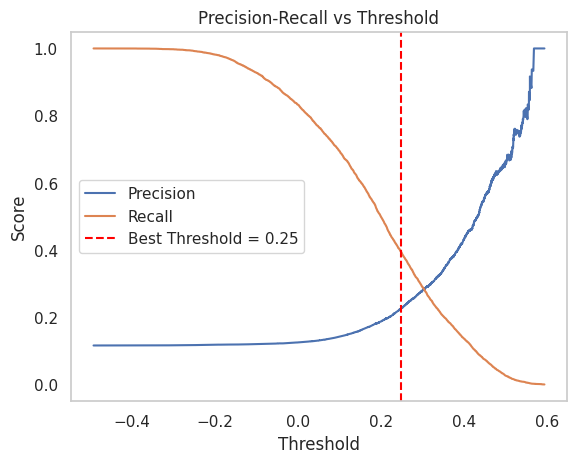

In [ ]:
precision, recall, thresholds = precision_recall_curve(y_test, y_pred)

plt.plot(thresholds, precision[:-1], label='Precision')
plt.plot(thresholds, recall[:-1], label='Recall')
plt.axvline(x=0.25, color='red', linestyle='--', label='Best Threshold = 0.25')
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision-Recall vs Threshold")
plt.legend()
plt.grid()
plt.show()

We applied Ridge Regression to assess whether historical loan features could predict default behavior in a simulated future scenario, representing economic shifts or policy changes. While Ridge is primarily a regression model, we adapted it to a classification setting by tuning the decision threshold.

The best threshold of 0.25 yielded an F1 score of 0.2878, with a recall of 0.3929 and precision of 0.2271, suggesting the model was moderately effective in identifying defaults. The ROC AUC of 0.6086 reflects fair discriminative ability, though not highly robust. While the model's R² value was negative (-0.0942), this metric is not reliable for binary classification tasks and was included only for completeness.

These results partially support our high-risk hypothesis, indicating that while the model can generalize patterns from historical data to future-like conditions, its predictive power is limited. This underscores the complexity of modeling long-term shifts in default behavior and highlights the importance of using more adaptive, classification-focused models for future forecasting.

#### Procedure 3: Bootstrap Resampling

In [ ]:
n_bootstrap = 100
random_state = 42
np.random.seed(random_state)

In [ ]:
X = df.drop(columns=['Default'])
X = pd.get_dummies(X, drop_first=True)
y = df['Default']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=random_state)

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
model = LogisticRegression(max_iter=1000, class_weight='balanced')

In [ ]:
boot_metrics = {
    'accuracy': [], 'precision': [], 'recall': [],
    'f1': [], 'roc_auc': []
}

In [ ]:
for i in range(n_bootstrap):
    indices = np.random.choice(len(X_train_scaled), size=len(X_train_scaled), replace=True)
    X_sample = X_train_scaled[indices]
    y_sample = y_train.iloc[indices]

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)
    cv_preds = []
    cv_probas = []
    y_true = []

    for train_idx, val_idx in skf.split(X_sample, y_sample):
        X_cv_train, X_cv_val = X_sample[train_idx], X_sample[val_idx]
        y_cv_train, y_cv_val = y_sample.iloc[train_idx], y_sample.iloc[val_idx]

        model.fit(X_cv_train, y_cv_train)
        preds = model.predict(X_cv_val)
        probas = model.predict_proba(X_cv_val)[:, 1]

        cv_preds.extend(preds)
        cv_probas.extend(probas)
        y_true.extend(y_cv_val)

    boot_metrics['accuracy'].append(accuracy_score(y_true, cv_preds))
    boot_metrics['precision'].append(precision_score(y_true, cv_preds, zero_division=0))
    boot_metrics['recall'].append(recall_score(y_true, cv_preds, zero_division=0))
    boot_metrics['f1'].append(f1_score(y_true, cv_preds, zero_division=0))
    boot_metrics['roc_auc'].append(roc_auc_score(y_true, cv_probas))

In [ ]:
metrics_df = pd.DataFrame(boot_metrics)

In [ ]:
summary = metrics_df.describe().loc[['mean', 'std']]
print(" Bootstrap Resampling Results (based on training set):")
print(summary)

 Bootstrap Resampling Results (based on training set):
      accuracy  precision    recall        f1   roc_auc
mean  0.681326   0.220610  0.688531  0.334152  0.750932
std   0.001455   0.001641  0.002195  0.002056  0.001718


In [ ]:
model.fit(X_train_scaled, y_train)
y_test_pred = model.predict(X_test_scaled)
y_test_proba = model.predict_proba(X_test_scaled)[:, 1]

In [ ]:
print("\n Final Evaluation on Test Set (Simulated Future):")
print(f"Accuracy:     {accuracy_score(y_test, y_test_pred):.4f}")
print(f"Precision:    {precision_score(y_test, y_test_pred):.4f}")
print(f"Recall:       {recall_score(y_test, y_test_pred):.4f}")
print(f"F1 Score:     {f1_score(y_test, y_test_pred):.4f}")
print(f"ROC AUC:      {roc_auc_score(y_test, y_test_proba):.4f}")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_test_pred))


 Final Evaluation on Test Set (Simulated Future):
Accuracy:     0.6824
Precision:    0.2237
Recall:       0.7026
F1 Score:     0.3394
ROC AUC:      0.7557
Confusion Matrix:
[[30681 14458]
 [ 1764  4167]]


To evaluate our high-risk hypothesis, we applied logistic regression with bootstrap resampling and cross-validation to assess the model’s robustness under simulated future conditions. On the test set, the model achieved an accuracy of 0.6824, recall of 0.7026, and an F1 score of 0.3394, along with a strong ROC AUC of 0.7557. These metrics suggest the model performs well in identifying defaulters and retains predictive power when exposed to unseen data.

Additionally, the bootstrap resampling on the training set confirmed stability, with low variance across 100 iterations. The average recall (0.6885) and ROC AUC (0.7509) indicate consistent detection of defaults and solid discriminative ability even across varying samples.

Together, these results support the hypothesis that historical patterns can be moderately predictive of future default behavior. However, the evolving nature of economic and policy conditions still necessitates ongoing model updates to maintain long-term reliability. Bootstrap resampling has helped reinforce the model’s generalizability under uncertainty, making it a promising approach for future risk modeling.



#### Comparison for Hypothesis 3

In [ ]:
models = ['LogReg', 'Ridge Regression', 'Boostrap Resampling']
accuracy = [0.6824, 0.7742, 0.6824]
recall =   [0.7026, 0.3929, 0.7026]
f1 =       [0.3394, 0.2878, 0.3394]
auc =      [0.7557, 0.6086, 0.7557]

x = np.arange(len(models))
width = 0.2

plt.figure(figsize=(10, 6))
plt.bar(x - 1.5*width, accuracy, width, label='Accuracy')
plt.bar(x - 0.5*width, recall, width, label='Recall')
plt.bar(x + 0.5*width, f1, width, label='F1 Score')
plt.bar(x + 1.5*width, auc, width, label='ROC AUC')

plt.xticks(x, models)
plt.ylabel('Score')
plt.title('Model Comparison for Hypothesis 3')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

NameError: name 'np' is not defined